# Le Langage des Machines - Acte V
## Word Embeddings : Comprendre la semantique

**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur

---

Dans les actes precedents, nous avons appris a :
- **Acte I** : Transformer du texte en vecteur (Bag of Words)
- **Acte II** : Ponderer les mots importants (TF-IDF)
- **Acte III** : Classifier les textes (Naive Bayes)
- **Acte IV** : Capturer l'ordre des mots (N-grammes)

Mais il reste un probleme : **"excellent" et "genial" sont des colonnes completement independantes**.

Dans cet acte, nous decouvrons les **Word Embeddings** avec un vrai modele pre-entraine.

## 1. Installation et chargement du modele

Nous utilisons **SpaCy** avec un modele francais pre-entraine sur des millions de textes.

In [3]:
# Installation (a executer une seule fois)
# !pip install spacy
# !python -m spacy download fr_core_news_md

In [4]:
import spacy
import numpy as np
from scipy.spatial.distance import cosine

# Charger le modele francais avec embeddings
print("Chargement du modele SpaCy francais...")
nlp = spacy.load("fr_core_news_md")
print("[OK] Modele charge !")
print(f"    Vocabulaire : {len(nlp.vocab)} mots")
print(f"    Dimensions des vecteurs : {nlp.vocab.vectors.shape[1]}")

Chargement du modele SpaCy francais...
[OK] Modele charge !
    Vocabulaire : 442 mots
    Dimensions des vecteurs : 300


## 2. Le probleme : avec BoW, les synonymes sont independants

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Avis sur SUCCEED
avis = [
    "Le cours est excellent",
    "Formation geniale",
    "Super formateur"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(avis)

print("=== Representation Bag of Words ===")
print(f"Colonnes : {vectorizer.get_feature_names_out()}")
print(f"\nMatrice :\n{X.toarray()}")
print("\n[!] 'excellent', 'geniale', 'super' sont dans des colonnes SEPAREES")
print("    Le modele ne sait pas qu'ils ont le meme sens !")

=== Representation Bag of Words ===
Colonnes : ['cours' 'est' 'excellent' 'formateur' 'formation' 'geniale' 'le' 'super']

Matrice :
[[1 1 1 0 0 0 1 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 1]]

[!] 'excellent', 'geniale', 'super' sont dans des colonnes SEPAREES
    Le modele ne sait pas qu'ils ont le meme sens !


## 3. Word Embeddings : voir les vrais vecteurs

Chaque mot est represente par un vecteur de 96 nombres (dans ce modele).
Ces nombres ont ete **appris automatiquement** sur des millions de textes.

In [6]:
# Obtenir le vecteur d'un mot
mot = "excellent"
vecteur = nlp(mot).vector

print(f"=== Vecteur du mot '{mot}' ===")
print(f"Nombre de dimensions : {len(vecteur)}")
print(f"\nLes 20 premieres valeurs :")
print(vecteur[:20].round(3))
print("\n[i] Ces nombres n'ont pas de signification humaine directe.")
print("    Ils ont ete appris automatiquement par le modele.")

=== Vecteur du mot 'excellent' ===
Nombre de dimensions : 300

Les 20 premieres valeurs :
[ 1.035  0.652 -2.236  1.857 -3.     0.336 -0.885  0.782 -0.211  0.539
 -1.731  0.364  1.265 -1.146 -0.197  2.272  1.404 -0.271 -0.88  -1.686]

[i] Ces nombres n'ont pas de signification humaine directe.
    Ils ont ete appris automatiquement par le modele.


In [7]:
# Comparer les vecteurs de plusieurs mots
mots = ["excellent", "genial", "super", "difficile", "voiture"]

print("=== Vecteurs de plusieurs mots (10 premieres dimensions) ===")
print("\n" + "-"*70)
for mot in mots:
    vec = nlp(mot).vector[:10]
    print(f"{mot:12} : {np.array2string(vec, precision=2, floatmode='fixed')}")
print("-"*70)
print("\n[i] Difficile de voir des patterns a l'oeil nu...")
print("    Mais mathematiquement, les synonymes ont des vecteurs proches !")

=== Vecteurs de plusieurs mots (10 premieres dimensions) ===

----------------------------------------------------------------------
excellent    : [ 1.04  0.65 -2.24  1.86 -3.00  0.34 -0.89  0.78 -0.21  0.54]
genial       : [-0.41  1.66 -3.55  0.49  2.61  0.09 -0.20  0.12 -0.95  0.30]
super        : [-1.03  2.04 -3.53  0.99 -0.39  0.21 -0.92 -0.00 -1.64 -0.22]
difficile    : [ 1.74 -0.44 -1.61  3.17 -2.16  1.49 -0.83  2.19  0.37 -0.18]
voiture      : [-1.61  0.09 -0.53 -0.33  0.42  2.00 -2.88  3.06 -1.52 -0.52]
----------------------------------------------------------------------

[i] Difficile de voir des patterns a l'oeil nu...
    Mais mathematiquement, les synonymes ont des vecteurs proches !


## 4. La vraie magie : mesurer la similarite entre mots

Meme si les vecteurs ne sont pas "lisibles", on peut mesurer leur **proximite**.

In [ ]:
# import spacy

# # Charger le modele francais pre-entraine
# nlp = spacy.load("fr_core_news_md")

# Trouver la similarite entre mots
doc1 = nlp("roi")
doc2 = nlp("reine")
print(doc1.similarity(doc2))
# --> 0.62


# L'equation magique (roi - homme + femme = ?)
from scipy.spatial.distance import cosine

vec_resultat = nlp("roi").vector - nlp("homme").vector + nlp("femme").vector

# Trouver le mot le plus proche du resultat
candidats = ["reine",  "princesse", "homme", "femme"]
for mot in candidats:
    sim = 1 - cosine(vec_resultat, nlp(mot).vector)
    print(f"{mot}: {sim:.2f}")
# --> reine: 0.71

In [34]:
nlp("femme").vector[:5]

array([-0.68879 , -3.0697  , -2.49    ,  1.6951  , -0.078261],
      dtype=float32)

In [ ]:
marcher - marche + nage = nager

In [47]:
from scipy.spatial.distance import cosine

def test_equation(a, b, c, candidats):
    print(f"\n=== {a} - {b} + {c} ===")
    
    vec_resultat = nlp(a).vector - nlp(b).vector + nlp(c).vector
    
    for mot in candidats:
        sim = 1 - cosine(vec_resultat, nlp(mot).vector)
        print(f"{mot:15}: {sim:.2f}")

# ============================================================
#  Genre
# roi - homme + femme = reine
# ============================================================

test_equation(
    "roi", "homme", "femme",
    ["reine", "homme", "femme"]
)

# ============================================================
# Pays / Capitale
# Paris - France + Italie = Rome
# ============================================================

test_equation(
    "Paris", "France", "Italie",
    ["Rome", "France", "Voiture"]
)

# ============================================================
#  Temps des verbes
# marcher - marche + nage = nager
# ============================================================

test_equation(
    "marcher", "marche", "nage",
    ["nager", "marcher", "marche"]
)

# ============================================================
# Comparatif
# plus grand - grand + petit = plus petit
# (SpaCy traite "plus grand" comme une phrase)
# ============================================================

test_equation(
    "plus grand", "grand", "petit",
    ["plus petit", "grand", "plus grand"]
)

# ============================================================
# Pluriel
# voitures - voiture + chat = chats
# ============================================================

test_equation(
    "voitures", "voiture", "chat",
    ["chats", "voitures", "voiture"]
)



=== roi - homme + femme ===
reine          : 0.71
homme          : 0.12
femme          : 0.38

=== Paris - France + Italie ===
Rome           : 0.61
France         : 0.13
Voiture        : 0.04

=== marcher - marche + nage ===
nager          : 0.80
marcher        : 0.54
marche         : 0.15

=== plus grand - grand + petit ===
plus petit     : 0.91
grand          : 0.23
plus grand     : 0.59

=== voitures - voiture + chat ===
chats          : 0.71
voitures       : 0.31
voiture        : -0.04


In [8]:
def similarite(mot1, mot2):
    """Calcule la similarite entre deux mots (0 = different, 1 = identique)"""
    return nlp(mot1).similarity(nlp(mot2))

print("=== Similarite entre mots ===")
print("(0 = completement different, 1 = identique)")

print("\n--- Mots positifs entre eux ---")
print(f"  excellent - genial     : {similarite('excellent', 'genial'):.3f}")
print(f"  excellent - super      : {similarite('excellent', 'super'):.3f}")
print(f"  genial - formidable    : {similarite('genial', 'formidable'):.3f}")

print("\n--- Mots negatifs entre eux ---")
print(f"  difficile - complique  : {similarite('difficile', 'complique'):.3f}")
print(f"  mauvais - nul          : {similarite('mauvais', 'nul'):.3f}")

print("\n--- Mots sans rapport ---")
print(f"  excellent - voiture    : {similarite('excellent', 'voiture'):.3f}")
print(f"  formation - chat       : {similarite('formation', 'chat'):.3f}")

print("\n[OK] Les synonymes ont une similarite ELEVEE !")
print("     Les mots sans rapport ont une similarite FAIBLE !")

=== Similarite entre mots ===
(0 = completement different, 1 = identique)

--- Mots positifs entre eux ---
  excellent - genial     : 0.044
  excellent - super      : 0.567
  genial - formidable    : 0.005

--- Mots negatifs entre eux ---
  difficile - complique  : 0.754
  mauvais - nul          : 0.267

--- Mots sans rapport ---
  excellent - voiture    : 0.173
  formation - chat       : -0.125

[OK] Les synonymes ont une similarite ELEVEE !
     Les mots sans rapport ont une similarite FAIBLE !


In [17]:
# Matrice de similarite
mots = ["excellent", "genial", "super", "difficile", "nul", "voiture"]

print("=== Matrice de similarite ===")
print("\n" + " "*12 + "  ".join([f"{m[:7]:>7}" for m in mots]))
print("-" * 65)
for mot1 in mots:
    ligne = f"{mot1:10} |"
    for mot2 in mots:
        sim = similarite(mot1, mot2)
        ligne += f"  {sim:>6.2f}"
    print(ligne)

print("\n[i] On voit clairement les 'clusters' de mots similaires !")

=== Matrice de similarite ===

            excelle   genial    super  diffici      nul  voiture
-----------------------------------------------------------------
excellent  |    1.00    0.04    0.57    0.37    0.10    0.17
genial     |    0.04    1.00    0.38    0.05    0.12    0.11
super      |    0.57    0.38    1.00    0.20    0.05    0.25
difficile  |    0.37    0.05    0.20    1.00    0.16    0.25
nul        |    0.10    0.12    0.05    0.16    1.00   -0.02
voiture    |    0.17    0.11    0.25    0.25   -0.02    1.00

[i] On voit clairement les 'clusters' de mots similaires !


## 5. Trouver les mots les plus similaires

In [10]:
def mots_similaires(mot_cible, candidats, n=5):
    """Trouve les n mots les plus similaires parmi les candidats"""
    vec_cible = nlp(mot_cible).vector
    
    similarites = []
    for mot in candidats:
        if mot != mot_cible:
            sim = 1 - cosine(vec_cible, nlp(mot).vector)
            similarites.append((mot, sim))
    
    similarites.sort(key=lambda x: x[1], reverse=True)
    return similarites[:n]

# Vocabulaire de test
vocabulaire = [
    "excellent", "genial", "super", "formidable", "top", "bien",
    "mauvais", "nul", "difficile", "confus", "complique",
    "cours", "formation", "formateur", "professeur", "ecole",
    "roi", "reine", "prince", "princesse", "homme", "femme",
    "chat", "chien", "voiture", "maison", "ordinateur"
]

print("=== Mots les plus similaires ===")
for mot_cible in ["excellent", "difficile", "roi", "chat"]:
    print(f"\n'{mot_cible}' est proche de :")
    for mot, sim in mots_similaires(mot_cible, vocabulaire):
        print(f"  {mot:15} : {sim:.3f}")

=== Mots les plus similaires ===

'excellent' est proche de :
  formidable      : 0.658
  super           : 0.567
  mauvais         : 0.431
  bien            : 0.375
  difficile       : 0.372

'difficile' est proche de :
  complique       : 0.754
  mauvais         : 0.507
  bien            : 0.506
  formidable      : 0.456
  excellent       : 0.372

'roi' est proche de :
  prince          : 0.755
  reine           : 0.628
  princesse       : 0.546
  homme           : 0.314
  femme           : 0.206

'chat' est proche de :
  chien           : 0.684
  femme           : 0.336
  homme           : 0.315
  super           : 0.278
  ordinateur      : 0.266


## 6. Visualisation des embeddings

Projetons les vecteurs en 2D pour visualiser les regroupements.

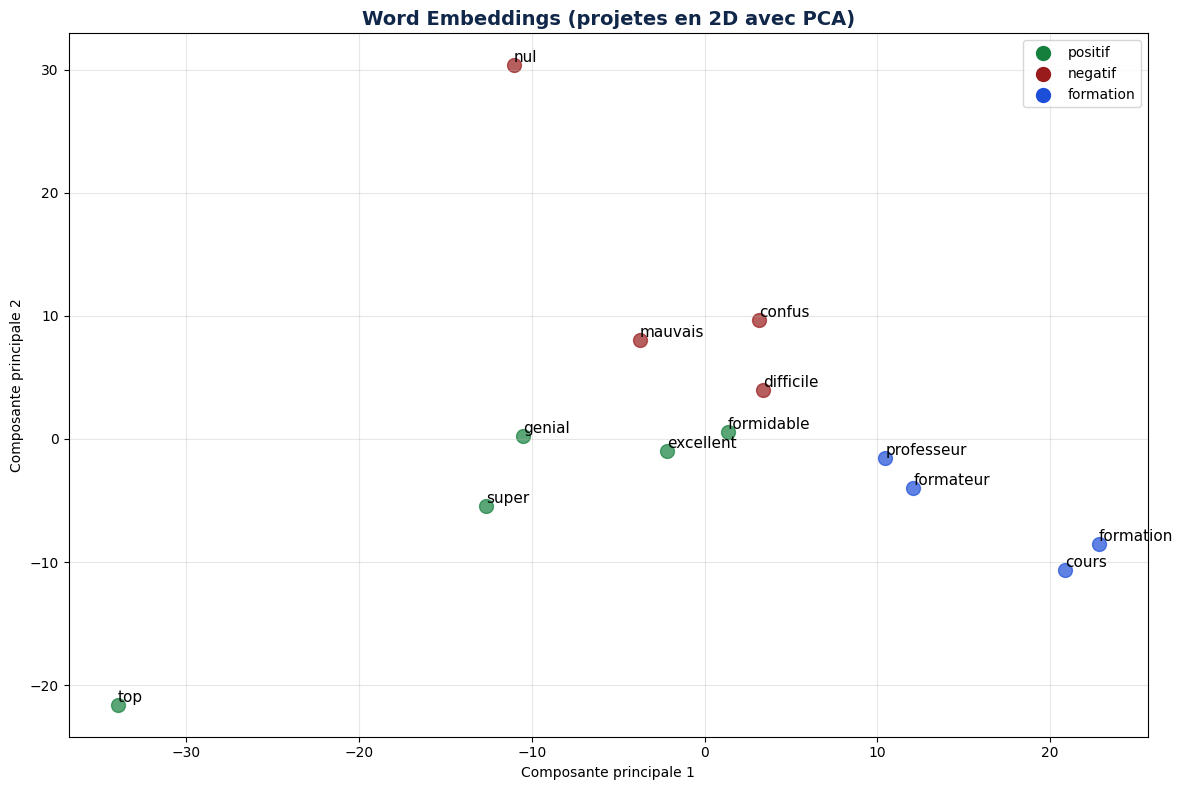

[OK] Les mots de meme categorie se regroupent !


In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Mots par categorie
mots_categories = {
    "positif": ["excellent", "genial", "super", "formidable", "top"],
    "negatif": ["mauvais", "nul", "difficile", "confus"],
    "formation": ["cours", "formation", "formateur", "professeur"],
}

# Recuperer les vecteurs
tous_mots = []
tous_vecteurs = []
tous_labels = []

for categorie, liste_mots in mots_categories.items():
    for mot in liste_mots:
        tous_mots.append(mot)
        tous_vecteurs.append(nlp(mot).vector)
        tous_labels.append(categorie)

# Reduction a 2D avec PCA
pca = PCA(n_components=2)
vecteurs_2d = pca.fit_transform(tous_vecteurs)

# Visualisation
couleurs = {"positif": "#15803d", "negatif": "#991b1b", "formation": "#1d4ed8"}

plt.figure(figsize=(12, 8))
for i, (mot, label) in enumerate(zip(tous_mots, tous_labels)):
    plt.scatter(vecteurs_2d[i, 0], vecteurs_2d[i, 1], 
                c=couleurs[label], s=100, alpha=0.7)
    plt.annotate(mot, (vecteurs_2d[i, 0], vecteurs_2d[i, 1]), 
                 fontsize=11, ha='left', va='bottom')

plt.title('Word Embeddings (projetes en 2D avec PCA)', 
          fontsize=14, fontweight='bold', color='#10274a')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.grid(True, alpha=0.3)

# Legende
for label, couleur in couleurs.items():
    plt.scatter([], [], c=couleur, label=label, s=100)
plt.legend()

plt.tight_layout()
plt.savefig('embeddings_2d.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[OK] Les mots de meme categorie se regroupent !")

## 7. L'equation magique : roi - homme + femme = ?

Les Word Embeddings permettent de faire des **operations arithmetiques** sur les mots !

In [12]:
def analogie(mot_a, mot_b, mot_c, candidats, n=5):
    """
    Resout l'analogie : mot_a - mot_b + mot_c = ?
    Exemple : roi - homme + femme = reine
    """
    vec_a = nlp(mot_a).vector
    vec_b = nlp(mot_b).vector
    vec_c = nlp(mot_c).vector
    
    # Calculer le vecteur resultat
    vec_resultat = vec_a - vec_b + vec_c
    
    # Exclure les mots de depart
    mots_exclus = {mot_a.lower(), mot_b.lower(), mot_c.lower()}
    
    # Trouver les mots les plus proches
    similarites = []
    for mot in candidats:
        if mot.lower() not in mots_exclus:
            sim = 1 - cosine(vec_resultat, nlp(mot).vector)
            similarites.append((mot, sim))
    
    similarites.sort(key=lambda x: x[1], reverse=True)
    return similarites[:n]

# Vocabulaire pour les analogies
vocab_analogies = [
    "roi", "reine", "prince", "princesse", 
    "homme", "femme", "garcon", "fille",
    "pere", "mere", "frere", "soeur",
    "acteur", "actrice", "chanteur", "chanteuse",
    "directeur", "directrice"
]

print("=== L'equation magique ===")

print("\nroi - homme + femme = ?")
for mot, sim in analogie("roi", "homme", "femme", vocab_analogies):
    print(f"  {mot:15} : {sim:.3f}")

print("\n" + "="*40)
print("\npere - homme + femme = ?")
for mot, sim in analogie("pere", "homme", "femme", vocab_analogies):
    print(f"  {mot:15} : {sim:.3f}")

print("\n" + "="*40)
print("\nprince - homme + femme = ?")
for mot, sim in analogie("prince", "homme", "femme", vocab_analogies):
    print(f"  {mot:15} : {sim:.3f}")

=== L'equation magique ===

roi - homme + femme = ?
  reine           : 0.708
  prince          : 0.662
  princesse       : 0.622
  fille           : 0.456
  soeur           : 0.293


pere - homme + femme = ?
  mere            : 0.819
  frere           : 0.819
  soeur           : 0.561
  fille           : 0.543
  garcon          : 0.368


prince - homme + femme = ?
  princesse       : 0.752
  fille           : 0.641
  reine           : 0.638
  roi             : 0.483
  soeur           : 0.463


## 8. Application : classification des avis SUCCEED

In [13]:
from sklearn.linear_model import LogisticRegression

# Avis SUCCEED avec labels
avis_labels = [
    ("Le cours est excellent je recommande", 1),
    ("Formation geniale tres enrichissante", 1),
    ("Super formateur pedagogique", 1),
    ("Top vraiment bien explique", 1),
    ("Formidable experience educative", 1),
    ("Cours difficile a suivre", 0),
    ("Formation confuse et mal organisee", 0),
    ("Nul je ne recommande pas", 0),
    ("Mauvaise experience decevante", 0),
    ("Incomprehensible et ennuyeux", 0),
]

# Transformer les textes en vecteurs
def texte_vers_vecteur(texte):
    """Moyenne des embeddings de tous les mots"""
    return nlp(texte).vector

X = np.array([texte_vers_vecteur(texte) for texte, _ in avis_labels])
y = np.array([label for _, label in avis_labels])

print(f"Donnees : {len(avis_labels)} avis")
print(f"Dimensions : {X.shape[1]}")

Donnees : 10 avis
Dimensions : 300


In [14]:
# Entrainer et tester
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

# Nouveaux avis
nouveaux_avis = [
    "Formation fantastique",
    "Cours tres bien fait",
    "Difficile a comprendre",
    "Vraiment top ce formateur",
    "Pas clair du tout",
]

print("=== Predictions ===")
for avis in nouveaux_avis:
    vec = texte_vers_vecteur(avis).reshape(1, -1)
    pred = clf.predict(vec)[0]
    proba = clf.predict_proba(vec)[0]
    sentiment = "POSITIF" if pred == 1 else "NEGATIF"
    print(f"\n'{avis}'")
    print(f"  --> {sentiment} (confiance: {max(proba)*100:.0f}%)")

=== Predictions ===

'Formation fantastique'
  --> POSITIF (confiance: 99%)

'Cours tres bien fait'
  --> POSITIF (confiance: 77%)

'Difficile a comprendre'
  --> NEGATIF (confiance: 100%)

'Vraiment top ce formateur'
  --> POSITIF (confiance: 100%)

'Pas clair du tout'
  --> POSITIF (confiance: 57%)


## 9. Recapitulatif

### Ce que nous avons appris

| Concept | Description |
|---------|-------------|
| **Word Embedding** | Vecteur appris automatiquement qui capture le sens |
| **Similarite** | Synonymes = vecteurs proches |
| **Analogie** | Operations mathematiques sur les mots |

### Points cles
- [+] Les dimensions n'ont **pas de signification humaine** directe
- [+] Les vecteurs sont **appris automatiquement** sur des millions de textes
- [+] La **similarite** revele les relations de sens
- [+] Utiliser des **modeles pre-entraines** (SpaCy, Word2Vec, etc.)

### Limite principale
- [x] Un seul vecteur par mot, quel que soit le contexte
- [x] "avocat" (fruit) = "avocat" (metier)

### Prochaine etape : Les Transformers
- BERT, GPT donnent un vecteur **different selon le contexte** !

---

**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur